In [1]:
import sys 
sys.path.insert(0,'../Modules/')
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from Block_WLS import Block_WLS
from Tensor_InducedSamp import Jacobi_Tensor_Induced_Sampling
from jacobi_sampling import jacobi_tensor_samp
from index_set import index_set
from pde_solvers import Viscous_Burgers_Spectral_Galerkin, sine_basis_vandermonde

def err(nu, idx_type, idx_param):
    
    ### Induced Sampling + Optimal Weights: 
    induced = True                      # If true: input functions sampled optimally and LS weights changed accordingly

    ### Approximation space parameters
    max_poly_degree =   10              # Maximum univariate degree of polynomials used to define operator basis 
    input_mode_truncation = 20          # Truncated Dimension of Input Function Space 
    output_mode_truncation = 150        # Truncated Dimension of Output Function Space 
    M_test = 1000                       # Number of test samples

    ### PDE parameters & solver for Viscous Burgers
    v = nu                              # Viscosity parameter
    T = 0.2                             # Final time for integration
    dt = 0.0001                         # Time step 
    lift_dim = 10*input_mode_truncation # Lifted dimension for Galerkin solve; solution projected to output_mode_truncation                   
    def pde_eval(input_data):
        M = input_data.shape[0]
        input_data_lifted = np.zeros([M, lift_dim])
        input_data_lifted[:, :input_mode_truncation] = input_data
        output_data = Viscous_Burgers_Spectral_Galerkin(v, dt, int(T/dt), input_data_lifted)[:, :output_mode_truncation]
        if not np.all(np.isfinite(np.linalg.norm(output_data, axis=1))):
            raise ValueError("Encountered inf/nan while solving PDE. Probably you want to decrease dt")
        return output_data

    jacobi_params = [[a**2, a**2]for a in range(input_mode_truncation)]

    ### Build Index Set
    weights = np.linspace(1, 0.01, input_mode_truncation)
    idx_set = index_set(input_mode_truncation, idx_param, max_index=max_poly_degree, weights=weights, max_size=10000, type=idx_type, p_norm = 1)    
    N = idx_set.shape[0]
    M = int(N * np.log(N))

    ### Generate Training Data:
    if induced:
        input_samples = input_samples = Jacobi_Tensor_Induced_Sampling(M, idx_set, jacobi_params, max_poly_degree)
    else: 
        input_samples = jacobi_tensor_samp(jacobi_params, M)
    output_samples = pde_eval(input_samples)

    ### Generate Testing Data:
    test_input_samples = jacobi_tensor_samp(jacobi_params, M_test)
    test_output_samples = pde_eval(test_input_samples)

    ### Instantiate the operator learning object.
    wls_operator = Block_WLS(jacobi_params, idx_set, input_samples, output_samples, induced)

    ### Apply the operator to test data
    test_approx_outputs = wls_operator.apply(test_input_samples)

    ### Compute relative (emirical) Boch Norm Error 
    test_boch = np.sqrt(np.mean(np.linalg.norm(test_approx_outputs - test_output_samples, axis = 1)**2))
    true_boch = np.sqrt(np.mean(np.linalg.norm(test_output_samples, axis = 1)**2))
    rel_boch_err = test_boch / true_boch

    return rel_boch_err, N

nus = [0.1, 0.01, 0.001]
lp_params = [1,2,3,4]
hc_params = [3.5,11,29,70]

lp_errs = np.zeros((len(nus),len(lp_params)))
lp_dims = np.zeros(len(lp_params))
hc_errs = np.zeros((len(nus),len(hc_params)))
hc_dims = np.zeros(len(hc_params))

for n,nu in enumerate(nus):
    idx_type = 'hc'
    for i,idx_param in enumerate(hc_params):
        rel_err, dim = err(nu, idx_type=idx_type, idx_param=idx_param)
        hc_dims[i] = dim
        hc_errs[n,i] = rel_err
    
    idx_type = 'lp'
    for i,idx_param in enumerate(lp_params):
        rel_err, dim = err(nu, idx_type=idx_type, idx_param=idx_param)
        lp_dims[i] = dim
        lp_errs[n,i] = rel_err
        
np.save('Data/hc_errs.npy', hc_errs)
np.save('Data/hc_dims.npy', hc_dims)
np.save('Data/lp_errs.npy', lp_errs)
np.save('Data/lp_dims.npy', lp_dims)

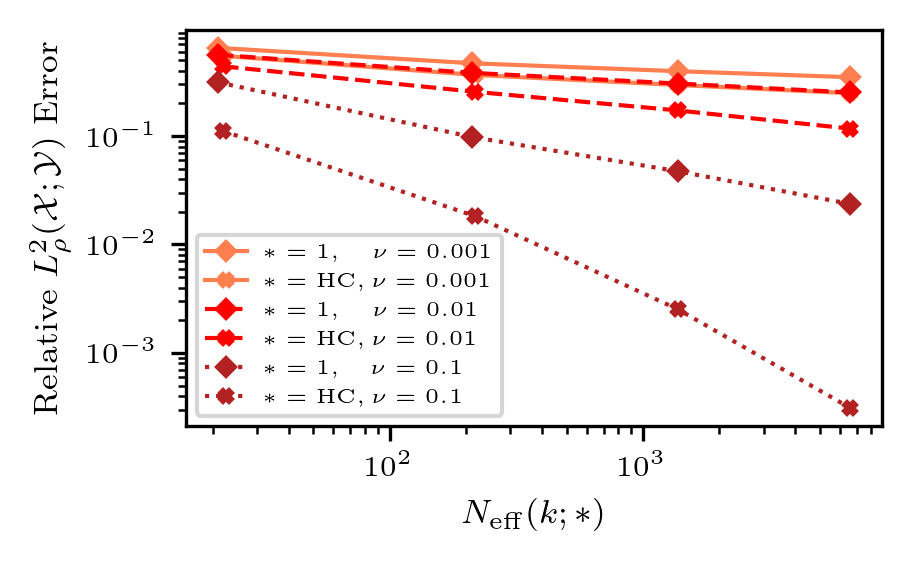

In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt
# General params 
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams['savefig.transparent'] = True
plt.rcParams["savefig.format"] = "pdf"
mpl.rcParams['figure.dpi'] = 300

mpl.rcParams["pdf.fonttype"] = 42   # TrueType
mpl.rcParams["ps.fonttype"] = 42

# Set figure sizes 
textwidth_pt = 422.52252                     
pt_to_inch = 1.0 / 72.27
subfig_ratio = 0.5
fig_width = textwidth_pt * pt_to_inch   *subfig_ratio         
fig_height = fig_width * 0.6                     
# Font sizes
base = 7  # match LaTeX \normalsize
plt.rcParams["font.size"] = base
plt.rcParams["axes.labelsize"] = base + 1      
plt.rcParams["axes.titlesize"] = base + 1      
plt.rcParams["xtick.labelsize"] = base         
plt.rcParams["ytick.labelsize"] = base         
plt.rcParams["legend.fontsize"] = base  - 2       
# Markersizes
markersize_small = 1
linewidth_small = 0.5
markersize_large = 3
linewidth_large = 1 

import numpy as np

Dims_HC = np.load("Data/hc_dims.npy")
err_HC = np.load("Data/hc_errs.npy")

Dims_ED = np.load("Data/lp_dims.npy")
err_ED = np.load("Data/lp_errs.npy")


plt.figure(figsize=(fig_width,fig_height), layout = 'constrained')
#plt.title(r"Relative $L^2_{\rho}(\mathcal{X}\,; \mathcal{Y})$ Error on 1000 Test Samples $u_0^i\sim \rho$")
plt.xlabel(r"$N_{\mathrm{eff}}(k;\ast)$")
plt.ylabel(r"Relative $L^2_\rho(\mathcal X; \mathcal Y)$ Error")
ax = plt.gca()
ax.set_yscale('log')
ax.set_xscale('log')

ax.plot(Dims_ED, err_ED[2,:],'D-', color = 'coral', label = r"$\ast = 1, \,\,\;\;  \nu = 0.001 $", linewidth = linewidth_large, markersize = markersize_large)
ax.plot(Dims_HC, err_HC[2,:],'X-', color = 'coral', label = r"$\ast = \mathrm{HC}, \nu = 0.001 $", linewidth = linewidth_large, markersize = markersize_large)

ax.plot(Dims_ED, err_ED[1,:],'D--', color = 'red', label = r"$\ast = 1, \,\;\; \, \nu = 0.01 $", linewidth = linewidth_large, markersize = markersize_large)
ax.plot(Dims_HC, err_HC[1,:],'X--', color = 'red', label = r"$\ast = \mathrm{HC}, \nu = 0.01 $", linewidth = linewidth_large, markersize = markersize_large)

ax.plot(Dims_ED, err_ED[0,:],'D:', color = 'firebrick', label = r"$\ast = 1, \,\,\,\,\, \nu = 0.1   $", linewidth = linewidth_large, markersize = markersize_large)
ax.plot(Dims_HC, err_HC[0,:],'X:', color = 'firebrick', label = r"$\ast = \mathrm{HC}, \nu = 0.1   $", linewidth = linewidth_large, markersize = markersize_large)

plt.legend( loc='best') #bbox_to_anchor=(1.05, 1.0),

plt.savefig("Plots/vB_Err.pdf",bbox_inches = 'tight')
plt.show()

In [2]:
err_ED.shape

(3, 4)